In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df = pd.read_csv("netflix_titles.csv")

df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [2]:
print("Rows and Columns:", df.shape)

df.info()

Rows and Columns: (8807, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [3]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [13]:
df.describe()


,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [14]:
df.describe(include='object')


,show_id,type,title,director,cast,country,date_added,rating,duration,listed_in,description
count,8807,8807,8807,6173,7982,7976,8797,8803,8804,8807,8807
unique,8807,2,8807,4528,7692,748,1767,17,220,514,8775
top,s1,Movie,Dick Johnson Is Dead,Rajiv Chilaka,David Attenborough,United States,"January 1, 2020",TV-MA,1 Season,"Dramas, International Movies","Paranormal activity at a lush, abandoned prope..."
freq,1,6131,1,19,19,2818,109,3207,1793,362,4


In [16]:
print("Duplicate Rows:", df.duplicated().sum())
df["type"].value_counts()

Duplicate Rows: 0


type
Movie      6131
TV Show    2676
Name: count, dtype: int64

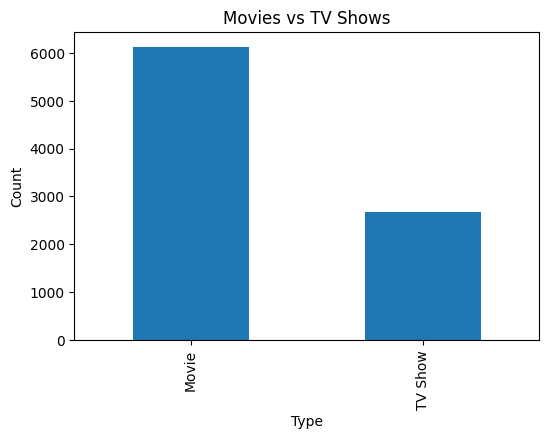

In [6]:
df["type"].value_counts().plot(
    kind="bar",
    figsize=(6,4)
)

plt.title("Movies vs TV Shows")
plt.xlabel("Type")
plt.ylabel("Count")

plt.show()

In [7]:
df["rating"].value_counts().head(10)

rating
TV-MA    3207
TV-14    2160
TV-PG     863
R         799
PG-13     490
TV-Y7     334
TV-Y      307
PG        287
TV-G      220
NR         80
Name: count, dtype: int64

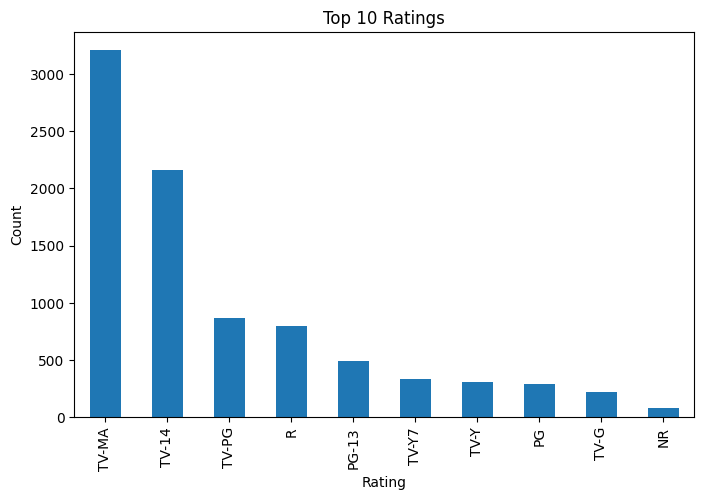

In [8]:
df["rating"].value_counts().head(10).plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Top 10 Ratings")
plt.xlabel("Rating")
plt.ylabel("Count")

plt.show()

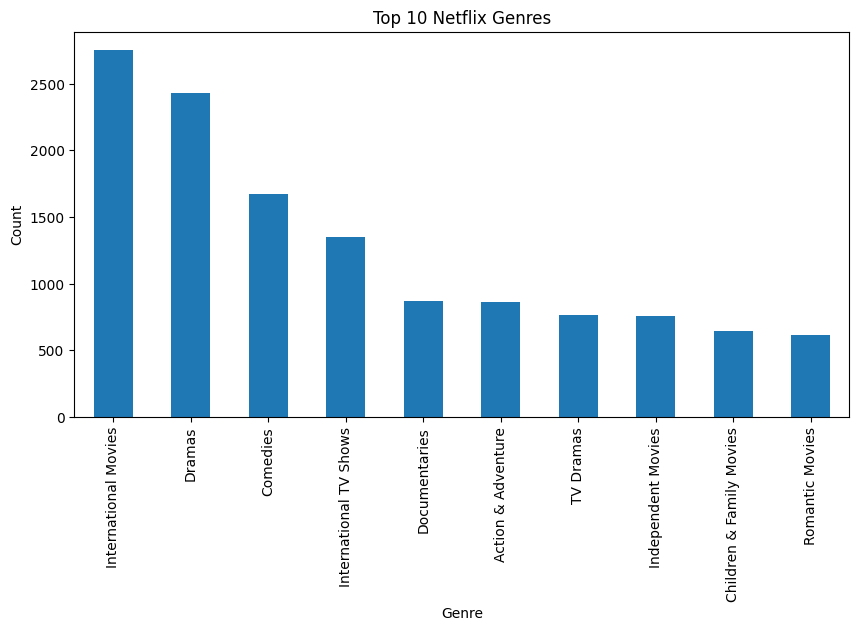

In [26]:
genres = df['listed_in'].str.split(', ').explode()

top_genres = genres.value_counts().head(10)

top_genres.plot(
    kind='bar',
    figsize=(10,5)
)

plt.title("Top 10 Netflix Genres")
plt.xlabel("Genre")
plt.ylabel("Count")

plt.show()

In [9]:
release_trend = df["release_year"].value_counts().sort_index()

release_trend.tail()

release_year
2017    1032
2018    1147
2019    1030
2020     953
2021     592
Name: count, dtype: int64

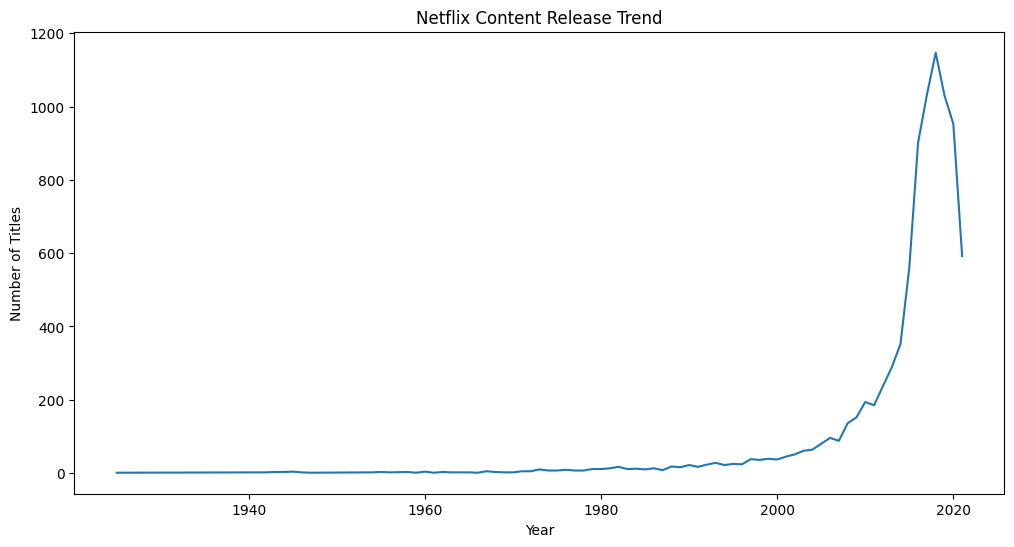

In [10]:
plt.figure(figsize=(12,6))

release_trend.plot()

plt.title("Netflix Content Release Trend")
plt.xlabel("Year")
plt.ylabel("Number of Titles")

plt.show()

In [12]:
top_countries = df["country"].value_counts().head(10)

top_countries


country
United States     2818
India              972
United Kingdom     419
Japan              245
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Egypt              106
Name: count, dtype: int64

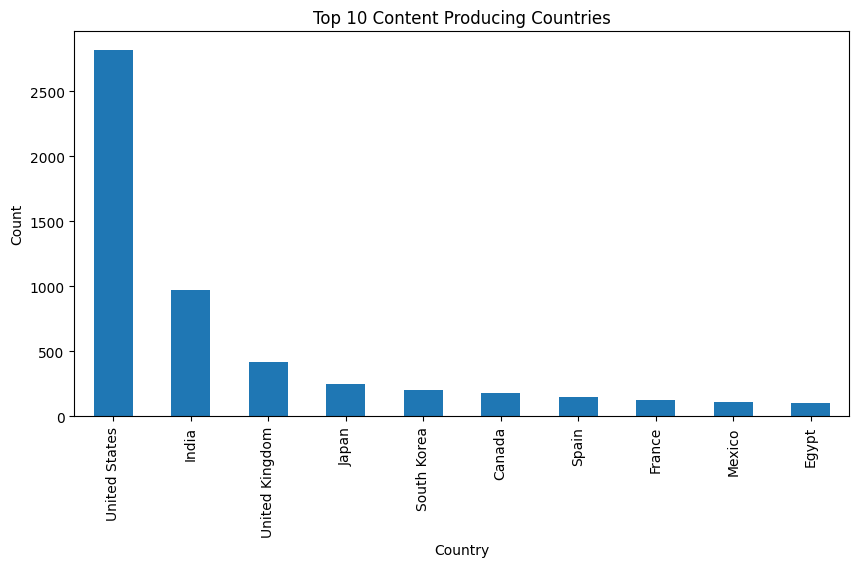

In [17]:
top_countries.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Top 10 Content Producing Countries")
plt.xlabel("Country")
plt.ylabel("Count")

plt.show()

In [18]:
numeric_df = df.select_dtypes(include=np.number)

numeric_df.head()

,release_year
0,2020
1,2021
2,2021
3,2021
4,2021


In [19]:
correlation = numeric_df.corr()

correlation

,release_year
release_year,1.0


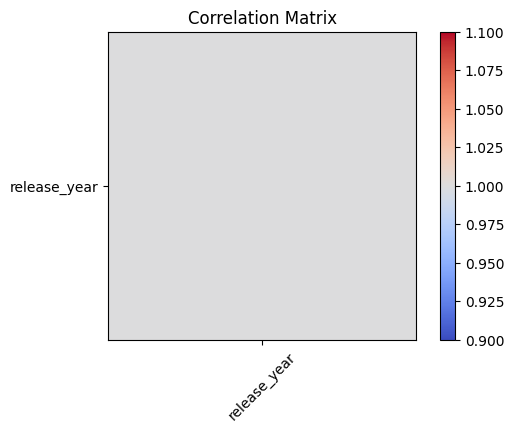

In [20]:
plt.figure(figsize=(6,4))

plt.imshow(correlation, cmap="coolwarm")

plt.colorbar()

plt.xticks(
    range(len(correlation.columns)),
    correlation.columns,
    rotation=45
)

plt.yticks(
    range(len(correlation.columns)),
    correlation.columns
)

plt.title("Correlation Matrix")

plt.show()

In [21]:
latest_year = df["release_year"].max()

print("Latest Release Year:", latest_year)

print(
    "Most Common Type:",
    df["type"].mode()[0]
)

Latest Release Year: 2021
Most Common Type: Movie


INSIGHTS

1. Movies are more common than TV Shows on Netflix.

2. TV-MA is one of the most frequent ratings.

3. Netflix content increased significantly after 2010.

4. The United States contributes the largest amount of content.

5. Release activity peaked in recent years.

6. Numerical correlation is limited because the dataset contains mostly categorical features.
